<a href="https://colab.research.google.com/github/atikhasan007/DeepLearning/blob/main/DL_Project/MNIST_Digit_Classification_using_Deep_Learning(Neural_Network).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MNIST Handwritten Dight Clasification using Deep Learning (Neural Network)**

importing the Dependencies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix



Loading the mnist data from keras.dataset

In [3]:
(x_train, y_train) , (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
type(x_train)

numpy.ndarray

In [5]:
# shape of the numpy array
print(x_train.shape, y_train.shape, x_test.shape,y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


- Training data = 60, 000 images
- test_data = 10,000 images


- Image dimension -> 28 x 28
- Grayscale Image -> 1 channel

In [7]:
# printing the 10th images

print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [8]:
print(x_train[10].shape)

(28, 28)


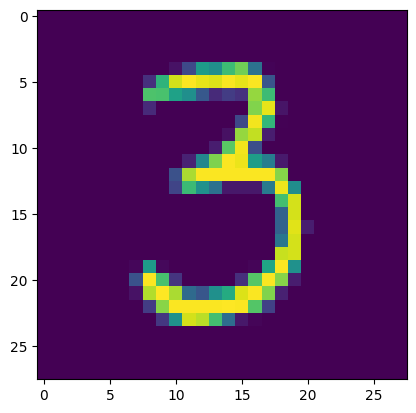

In [9]:
# display the image

plt.imshow(x_train[50])
plt.show()

# print the corresponding lebel


In [10]:
print(y_train[50])

3


Image Labels

In [11]:
print(y_train.shape, y_test.shape)

(60000,) (10000,)


In [12]:
# unique values in y_train
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [13]:
# unique values in y_test
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]


we can use these leabels as such or we can also apply **One Hot Encoding**

all the images have the same dimensions in this dataset, if not , we have to resize all the images to a common dimension


In [14]:
# scalling  the values
x_train = x_train/255
x_test = x_test/255
# 0 is minimum value and maximum value is 1

In [16]:
# printing the 10th image
print(x_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    


# building the Neural Network

In [17]:
# setting up the layers of the neural network

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# compiling the Neural Network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [21]:
# training the Neural Network
model.fit(x_train,y_train , epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9589 - loss: 0.1402
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9692 - loss: 0.1043
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9751 - loss: 0.0834
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9800 - loss: 0.0674
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9833 - loss: 0.0561
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9857 - loss: 0.0470
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9880 - loss: 0.0410
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9893 - loss: 0.0357
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9908 - loss: 0.0316
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9916 - loss: 0.0269


Training data accuracy = 98.9%

**Accuracy on Test Data**

In [22]:
loss, accuracy = model.evaluate(x_test, y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9710 - loss: 0.1148
0.9710000157356262


Test data accuracy = 97.1%

In [23]:
print(x_test.shape)

(10000, 28, 28)


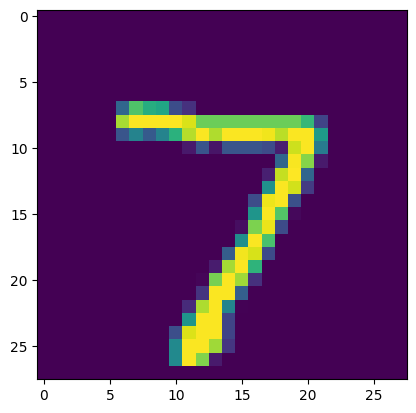

In [25]:
# first data point in x_test
plt.imshow(x_test[0])
plt.show()

In [26]:
print(y_test[0])

7


In [27]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [28]:
print(y_pred.shape)

(10000, 10)


In [29]:
print(y_pred[0])

[4.9768551e-07 6.5881238e-09 3.8167413e-03 9.4703197e-01 9.1555016e-08
 2.6363472e-03 5.1307159e-10 9.9998099e-01 3.0026078e-01 2.0078011e-01]


model.predict() gives the prediction probability of each class for that data point

In [34]:
# converting the prediction probabilities to class label
label_for_fast_image = np.argmax(y_pred[0])
print(label_for_fast_image)

7


In [35]:
# converting the prediction probabilites to class labelfor all test data points
y_pred_labels = [np.argmax(i) for i in y_pred]
print(y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

In [36]:
print(y_pred)

[[4.97685505e-07 6.58812382e-09 3.81674129e-03 ... 9.99980986e-01
  3.00260782e-01 2.00780109e-01]
 [5.74572514e-05 7.88644515e-03 9.99993920e-01 ... 2.17284756e-16
  7.11709261e-03 1.00698060e-07]
 [1.87883904e-06 9.99843359e-01 9.22014862e-02 ... 8.39251101e-01
  3.89352888e-01 4.26492246e-04]
 ...
 [1.15039944e-09 1.34945767e-05 6.93903305e-03 ... 9.56035554e-01
  2.10845731e-02 9.75184858e-01]
 [1.11512776e-07 5.95448739e-08 2.07005513e-07 ... 9.36743072e-06
  9.98376787e-01 1.05322533e-05]
 [3.28942746e-01 8.47404777e-08 1.01006709e-01 ... 1.28050522e-06
  4.29247448e-04 1.74161278e-06]]


- y_test --> True labels
- y_pred_labels --> Predicted Labels

Confusion matrix

In [38]:
conf_mat = confusion_matrix(y_test, y_pred_labels)


In [39]:
print(conf_mat)

tf.Tensor(
[[ 961    0    2    1    1    2    3    3    2    5]
 [   0 1118    2    2    4    1    1    2    5    0]
 [   5    1  984    7    8    0    3   11   13    0]
 [   0    0    5  979    1    1    2    4    9    9]
 [   0    0    1    0  961    0    5    4    3    8]
 [   2    0    0   15    1  851    5    1    7   10]
 [   3    2    2    1    9    7  929    1    4    0]
 [   0    2    6    0    1    0    0 1005    3   11]
 [   4    0    3    3    6    1    4    2  947    4]
 [   1    3    0    2   17    2    0    5    4  975]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

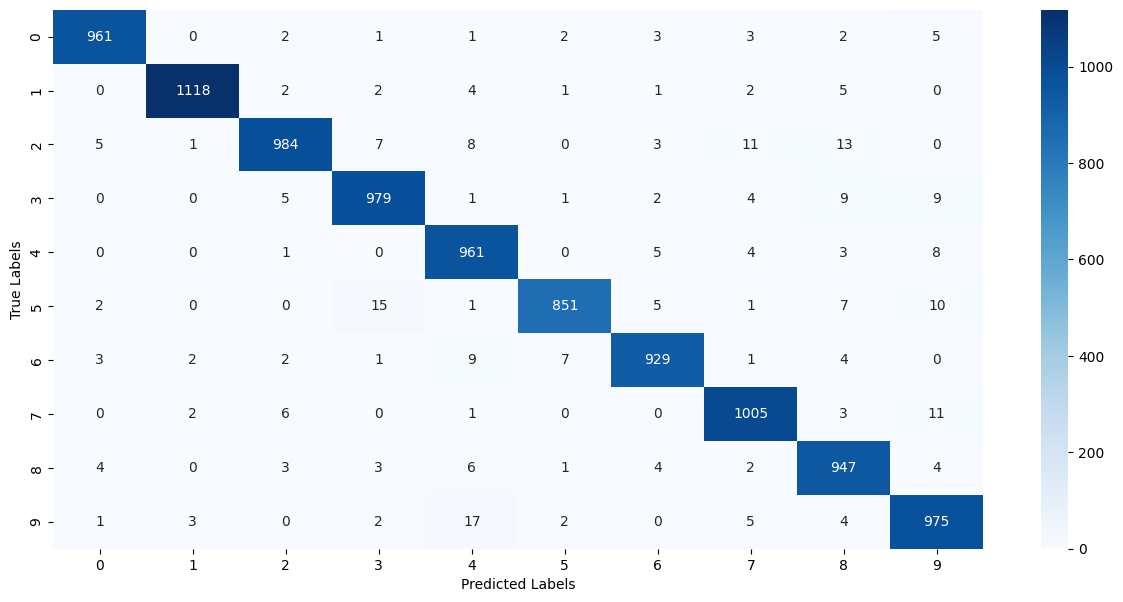

In [40]:
plt.figure(figsize = (15,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')


**Building a Predictive System**

In [44]:
input_image_path = '/content/seven.jpg'


In [45]:
input_image = cv2.imread(input_image_path)

In [46]:
type(input_image)

numpy.ndarray

In [48]:
#print(input_image)

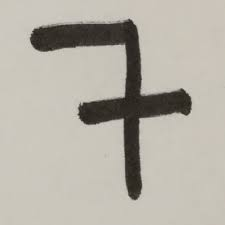

In [49]:
cv2_imshow(input_image)

In [50]:
input_image.shape

(225, 225, 3)

In [51]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

In [52]:
grayscale.shape

(225, 225)

In [53]:
input_image_resize = cv2.resize(grayscale, (28,28))

In [54]:
input_image_resize

array([[199, 200, 200, 199, 200, 200, 200, 199, 199, 199, 198, 198, 198,
        198, 198, 198, 197, 198, 198, 198, 197, 197, 197, 197, 198, 197,
        197, 198],
       [200, 200, 200, 200, 200, 200, 200, 199, 198, 198, 198, 198, 198,
        196, 196, 197, 197, 198, 198, 197, 197, 197, 198, 197, 198, 197,
        197, 197],
       [200, 200, 200, 199, 199, 199, 199, 195, 198, 196, 193, 194, 191,
        194, 193, 152, 180, 197, 197, 198, 198, 197, 198, 197, 198, 197,
        197, 197],
       [200, 200, 199, 196, 152,  75,  45,  56,  52,  51,  52,  55,  48,
         52,  53,  46,  46, 203, 197, 197, 197, 197, 198, 198, 197, 197,
        195, 195],
       [200, 199, 199, 198,  47,  50,  47,  44,  45,  48,  47,  51,  49,
         44,  54,  47,  36, 195, 197, 197, 196, 197, 198, 198, 197, 197,
        195, 196],
       [199, 200, 199, 199,  45,  47,  52,  47,  49,  53,  51,  60,  57,
         63,  83, 121,  43, 194, 196, 197, 197, 197, 197, 197, 197, 198,
        196, 196],
       [200, 199, 199, 198, 196, 170, 190, 199, 195, 196, 194, 196, 194,
        194, 193, 184,  40, 167, 197, 198, 198, 197, 196, 197, 197, 198,
        197, 197],
       [200, 200, 198, 198, 198, 198, 198, 197, 196, 197, 196, 196, 196,
        194, 193, 192,  44, 106, 196, 197, 198, 197, 197, 198, 198, 198,
        198, 197],
       [200, 198, 199, 198, 198, 199, 198, 197, 197, 197, 196, 196, 196,
        194, 193, 190,  42,  92, 196, 197, 197, 197, 197, 198, 198, 198,
        198, 197],
       [199, 199, 199, 199, 198, 199, 198, 198, 198, 198, 195, 196, 197,
        194, 194, 194,  41,  71, 196, 197, 197, 197, 197, 197, 196, 197,
        198, 197],
       [199, 199, 199, 199, 198, 199, 199, 198, 198, 197, 197, 196, 195,
        195, 194, 181,  42,  77, 196, 196, 195, 196, 196, 197, 197, 197,
        196, 195],
       [199, 199, 200, 200, 199, 199, 199, 198, 198, 198, 196, 195, 194,
        196, 194, 166,  42, 136, 185, 179, 133,  70,  54, 196, 196, 196,
        196, 196],
       [200, 200, 200, 199, 200, 200, 199, 198, 198, 192, 197, 194, 122,
         62,  44,  53,  40,  44,  49,  49,  53,  49,  45,  51, 198, 197,
        196, 196],
       [200, 200, 200, 199, 199, 199, 198, 199, 198, 191,  50,  48,  42,
         44,  42,  43,  44,  45,  42,  49,  49,  53,  49,  49, 195, 196,
        196, 197],
       [199, 200, 200, 199, 199, 199, 198, 199, 198, 185,  38,  45,  42,
         46,  57,  40,  45,  50,  65, 134, 187, 193, 195, 191, 196, 196,
        196, 196],
       [200, 200, 199, 199, 199, 199, 199, 198, 198, 196, 183, 124, 200,
        203, 197,  57,  43, 199, 196, 196, 196, 196, 196, 197, 196, 197,
        197, 197],
       [199, 200, 199, 199, 199, 199, 199, 199, 198, 198, 198, 197, 198,
        196, 195,  57,  43, 187, 197, 197, 197, 197, 198, 198, 197, 197,
        197, 197],
       [199, 199, 199, 199, 200, 199, 199, 199, 198, 198, 198, 198, 197,
        197, 195,  79,  44, 192, 197, 198, 198, 197, 197, 197, 196, 197,
        196, 197],
       [199, 199, 200, 200, 199, 199, 199, 199, 199, 199, 198, 198, 197,
        197, 196, 101,  43, 184, 196, 197, 197, 198, 198, 197, 197, 196,
        196, 196],
       [199, 199, 199, 199, 199, 199, 199, 198, 199, 198, 198, 197, 197,
        192, 196, 133,  43, 181, 196, 198, 198, 198, 198, 197, 196, 196,
        196, 197],
       [199, 199, 199, 199, 199, 199, 198, 198, 198, 198, 198, 197, 197,
        197, 195, 164,  37, 149, 197, 198, 197, 197, 197, 196, 197, 197,
        196, 197],
       [199, 199, 199, 199, 199, 198, 198, 197, 198, 198, 198, 198, 197,
        196, 194, 177,  42, 140, 198, 196, 197, 197, 196, 197, 197, 196,
        194, 196],
       [199, 199, 199, 199, 199, 199, 198, 197, 198, 198, 198, 196, 196,
        195, 195, 182,  43,  62, 196, 198, 196, 197, 196, 197, 196, 196,
        196, 195],
       [199, 199, 199, 199, 199, 199, 197, 197, 198, 197, 197, 197, 197,
        196, 196, 188,  41,  58, 196, 197, 197, 197, 196, 196, 196, 197,
        197, 195],
       [198, 198, 198, 198, 198, 198, 19

In [55]:
input_image_resize.shape

(28, 28)

In [56]:
cv2_imshow(input_image_resize)

In [57]:
input_image_resize = input_image_resize/255
# all the value 0 to 1 range

In [58]:
image_reshaped = np.reshape(input_image_resize, [1,28,28])

In [59]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[2.3105198e-12 1.8611202e-21 9.9999696e-01 7.8224649e-10 6.8992599e-33
  8.8571887e-03 3.4944077e-14 1.0000000e+00 1.0579370e-02 9.4011264e-15]]


In [60]:
input_pred_label = np.argmax(input_prediction)

In [61]:
input_pred_label

np.int64(7)

The model predicted correctly.

**Predicted System**

In [65]:
# input_image_path = '/content/seven.jpg'

input_image_path = input("Path of the image to be predicted : ")
input_image = cv2.imread(input_image_path)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

input_image_resize = cv2.resize(grayscale, (28,28))

input_image_resize = input_image_resize/255

image_reshaped = np.reshape(input_image_resize, [1,28,28])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)
print("the Handwritten Digit is recognised as " , input_pred_label)

Path of the image to be predicted : /content/seven.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
the Handwritten Digit is recognised as  7
